# 6.a) Derivation 
Looking for derivation of 
$$
f'(x_j) \approx
= \frac{-f_{j+2} + 4 f_{j+1} - 3 f_j}{2h}.
$$
and $O(h²)$ using Taylor expansion where:
$$
x_j = x_0 + jh, \qquad f_j = f(x_j).
$$

Assume a general linear combination of the terms:
$$
f'(x_j) \approx a f_j + b f_{j+1} + c f_{j+2},
$$


where $a,b,c$ are constants to be determined.

Expand $f_{j+1}$ and $f_{j+2}$ about $x_j$ while noting that:
$$
x_{j+1} = x_j + h \\
x_{j+2} = x_j + 2h
$$
Now, the general expression for a Taylor expansion is:

$$
f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}\,(x-a)^n
$$
Substituting $x = x_j + h$ and $a = x_j$ we get $x - a = x - x_j = h$ and therefore:

$$
f_{j+1} = f(x_j + h)
= f(x_j) + h f'(x_j) + \frac{h^2}{2} f''(x_j) + \frac{h^3}{6} f^{(3)}(x_j)
+ \cdot \cdot \cdot).
$$

$$
f_{j+2} = f(x_j + 2h)
= f(x_j) + 2h f'(x_j) + 2h^2 f''(x_j)
+ \frac{4}{3} h^3 f^{(3)}(x_j) + \cdot \cdot \cdot.
$$
Let $f_j = f(x_j),\; f'_j = f'(x_j),\; f''_j = f''(x_j),\; f^{(3)}_j = f^{(3)}(x_j)$:

$$
\Rightarrow\quad
f_{j+1} = f_j + h f'_j + \frac{h^2}{2} f''_j + \frac{h^3}{6} f^{(3)}_j + \cdot \cdot \cdot,
$$

$$
f_{j+2} = f_j + 2h f'_j + 2h^2 f''_j + \frac{4}{3} h^3 f^{(3)}_j + \cdot \cdot \cdot.
$$

Substitute these into the general combination $a f_j + b f_{j+1} + c f_{j+2}$ and collect like terms in $f_j, f'_j, f''_j$

$$
a f_j + b f_{j+1} + c f_{j+2}
= (a + b + c)\, f_j
+ (b + 2c)\, h f'_j
+ \left(\frac{b}{2} + 2c\right) h^2 f''_j
+ \left(\frac{b}{6} + \frac{4c}{3}\right) h^3 f^{(3)}_j
+ \cdot \cdot \cdot.
$$

We want this to approximate $f'_j$ with error term $\propto h²$, i.e $O(h²)$:


$$
a f_j + b f_{j+1} + c f_{j+2}
= f'_j + O(h^2).
$$

Therefore, let:

$$
\begin{cases}
a + b + c = 0, & \text{(no constant } f_j \text{ term)} \\[4pt]
(b + 2c) h = 1, & \text{(coefficient of } f'_j \text{ is } 1) \\[4pt]
\displaystyle \left(\frac{b}{2} + 2c\right) h^2 = 0, & \text{(eliminate } f''_j \text{ term to get error } O(h^2))
\end{cases}
$$.

Solving the system we get:
$$
a = -\frac{3}{2h}, \qquad
b = \frac{2}{h}, \qquad
c = -\frac{1}{2h}.
$$

Insert back into the linear combination:

$$
f'(x_j) \approx
-\frac{3}{2h} f_j + \frac{2}{h} f_{j+1} - \frac{1}{2h} f_{j+2}
= \frac{-f_{j+2} + 4 f_{j+1} - 3 f_j}{2h}. \quad \text{Q.E.D}
$$

From the expansions, the remaining term is the leading truncation error


$$
\left(\frac{b}{6} + \frac{4c}{3}\right) h^3 f^{(3)}_j
$$

and with inserted values of $b, c$ this is equal to: 

$$
-\frac{1}{3} h^2 f^{(3)}(x_j)
$$

and so the method is of order $O(h²)$

# 6.b)

Beräkna approximationen av förstaderivatan för funktionen $f(x) = sin(e^x)$ vid $x=0.75$ med differensformlerna (8), (12) och (13) med $h = 2^{-k}$ för $k = 1,2,...,8$. Plotta
absolutbeloppet av felet i båda fallen som funktion av $\frac{1}{h}$ med Python-funktionen
loglog. Plotta en referenskurva med det teoretiska trunkeringsfelet, i samma figur,
som visar att felet avtar som förväntat (förklara vad du gör).



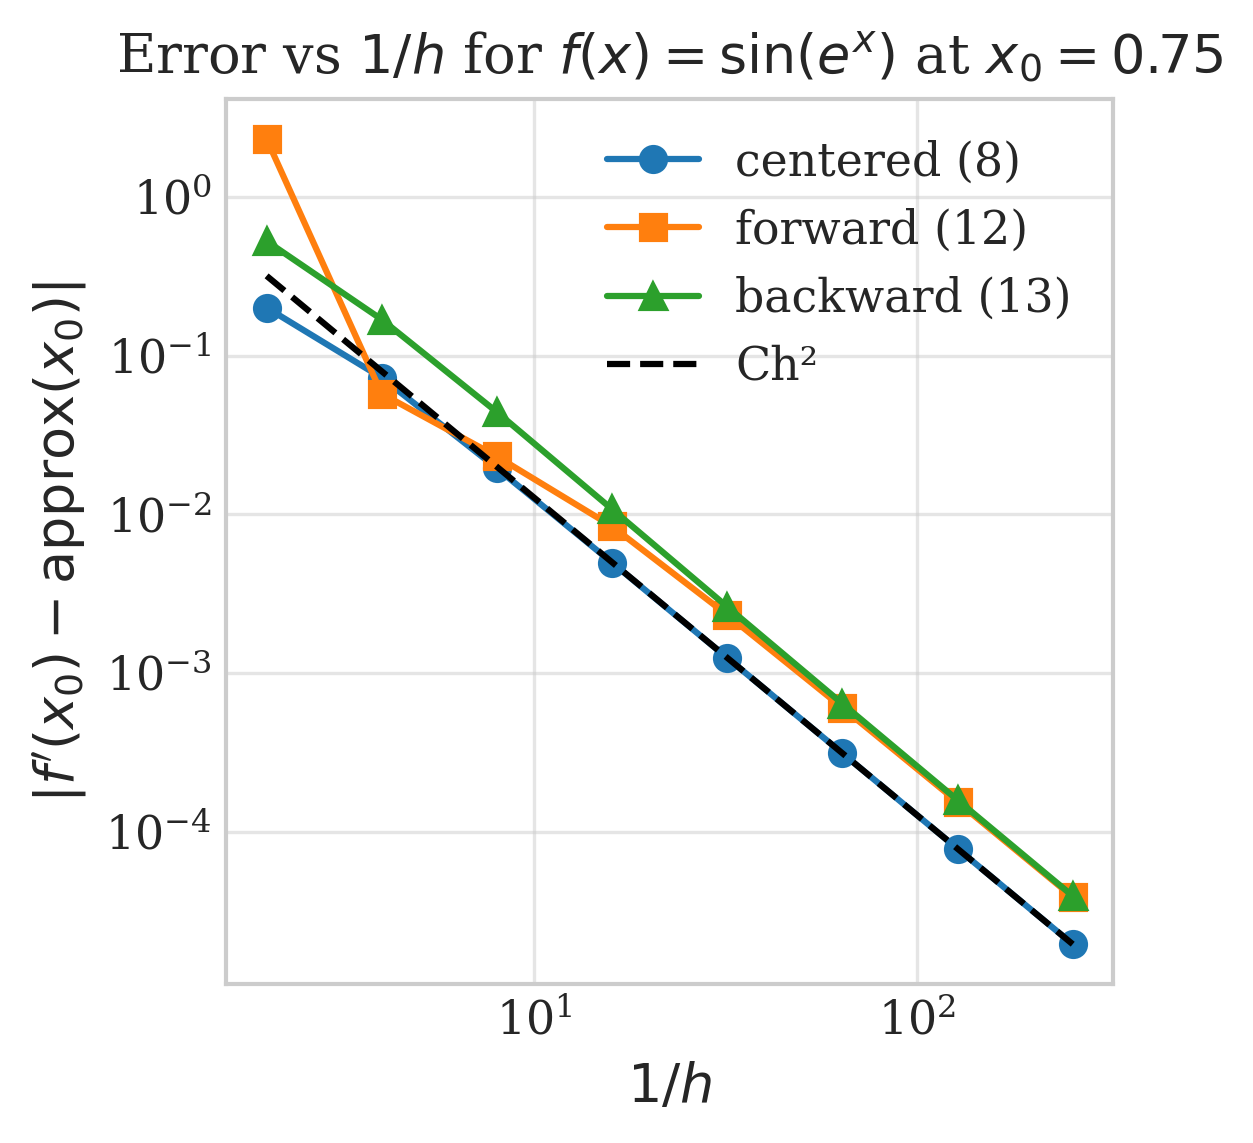

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

K: list[int] = [x + 1 for x in range(8)]
x0 = 0.75


def h(k: int) -> float:
    return 2 ** (-k)


def f(x: float) -> np.float64:
    return np.sin(np.exp(x))


def f_prime_analytical(x: float) -> np.float64:
    return np.exp(x) * np.cos(np.exp(x))


def diff_8(f: callable, x: float, h: float) -> float:
    """
    Second-order centered finite difference method.
    """
    return (f(x + h) - f(x - h)) / (2 * h)


def diff_12(f: callable, x: float, h: float) -> float:
    """
    Second-order forward (one-sided) finite difference method.
    """
    return (-f(x + 2 * h) + 4 * f(x + h) - 3 * f(x)) / (2 * h)


def diff_13(f: callable, x: float, h: float) -> float:
    """
    Second-order backward (one-sided) finite difference method.
    """
    return (3 * f(x) - 4 * f(x - h) + f(x - 2 * h)) / (2 * h)


errs_8: list = []
errs_12: list = []
errs_13: list = []
hs: list = []

for k in K:
    hk = h(k)
    approx8 = diff_8(f, x0, hk)
    approx12 = diff_12(f, x0, hk)
    approx13 = diff_13(f, x0, hk)

    err8 = abs(approx8 - f_prime_analytical(x0))
    err12 = abs(approx12 - f_prime_analytical(x0))
    err13 = abs(approx13 - f_prime_analytical(x0))

    hs.append(hk)
    errs_8.append(err8)
    errs_12.append(err12)
    errs_13.append(err13)

hs_inv = [1 / h for h in hs]
# ------------- Theoretical Error -------------
# For second order method the truncation error E(h): E(h) ≈ Ch², so C = E/h²:
C = errs_8[-1] / (hs[-1] ** 2)
ref_errs = [C * (h**2) for h in hs]

# [PLOT_START]
plt.style.use("seaborn-v0_8-whitegrid")
SMALL, MED, BIG = 11, 13, 14
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": MED,
        "axes.titlesize": MED,
        "axes.labelsize": MED,
        "xtick.labelsize": SMALL,
        "ytick.labelsize": SMALL,
        "legend.fontsize": SMALL,
        "figure.dpi": 300,
    }
)

plt.figure(figsize=(4, 4))

plt.loglog(hs_inv, errs_8, "o-", label="centered (8)")
plt.loglog(hs_inv, errs_12, "s-", label="forward (12)")
plt.loglog(hs_inv, errs_13, "^-", label="backward (13)")
plt.loglog(hs_inv, ref_errs, "k--", label=r"Ch²")

plt.xlabel(r"$1/h$")
plt.ylabel(r"$|f^\prime(x_0) - \text{approx}(x_0)|$")
plt.title(rf"Error vs $1/h$ for $f(x)=\sin(e^x)$ at $x_0={x0}$")

# plt.grid(False)
plt.grid(True, ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# [PLOT_END]


# Discussion

All error curves parallell to the reference one $E(h) \approx Ch²$. \
This shows that they all follow the theoretical truncation error, i.e the error scales like $h²$ for all methods. \
Amplitude difference is due to different size $C$ in front of $h²$. \
For large $h$ some higher order error terms ($O(h³),O(h⁴)$ and so on) might still be large enough to noticably affect the error before we enter the "asymptotic regime" where $h \to 0$ renders the higher order terms negligible.


# Uppgift 7. Förberedelseuppgift
Diskretisera intervallet $[0, L]$ med fyra delintervall ($N = 4$) och ersätt $T''(x)$ i 14 med
den finita differens approximation i 9. Ställ upp det resulterande olinjära ekvations-
systemet som ska lösas samt dess Jacobianmatris. Beskriv även hur du planerar lösa
det olinjära ekvationssystemet.

For some second order DE: $ \frac{d²T}{dx²} = \omega(x)$, with $\omega(x_j) = \omega_j$

Central finite difference: $f''(x_j) = \frac{ \omega_{j+1} - 2 \omega_{j} + \omega_{j-1} }{h²} + \mathcal{O} (h²) \quad (9)$

$N = 4$ and $[0, L]$ results in the grid $j \isin \{0,1,2,3,4\}$ with interior points $ j = 1,2,3$:

$$
h = \frac{L - 0}{N} = \frac{L}{4}, \\

\quad x_0 = 0, \quad x_1 = h = \frac{L}{4}, \quad x_2 = 2h = \frac{L}{2}, \\ \quad x_3 = 3h = 3 \frac{L}{4}, \quad x_4 = 4h = L
$$
In our case $\omega_j = \alpha_1 ( T(x_j) - T(\infty) ) + \alpha_2 f(T(x_j))$. \
Now, let $T_j = T(x_j)$. \
For the interior points we then get: 

$$
\frac{T_{2} - 2T_{1} + T_{0}}{h^2}
= \alpha_1\big(T_1 - T(\infty)\big) + \alpha_2 f(T_1),
$$

$$
\frac{T_{3} - 2T_{2} + T_{1}}{h^2}
= \alpha_1\big(T_2 - T(\infty)\big) + \alpha_2 f(T_2),
$$
$$
\frac{T_{4} - 2T_{3} + T_{2}}{h^2}
= \alpha_1\big(T_3 - T(\infty)\big) + \alpha_2 f(T_3)
$$

Now note that $T(0) = T_s, \quad T(L) = T_L$: 
$$
\frac{T_2 - 2T_1}{h^2}
= \alpha_1\big(T_1 - T(\infty)\big) + \alpha_2 f(T_1) - \frac{T_s}{h^2}
$$

$$
\frac{T_3 - 2T_2 + T_1}{h^2}
= \alpha_1\big(T_2 - T(\infty)\big) + \alpha_2 f(T_2)
$$

$$
\frac{T_2 - 2T_3}{h^2}
= \alpha_1\big(T_3 - T(\infty)\big) + \alpha_2 f(T_3) - \frac{T_L}{h^2}
$$

Rewrite system in compact matrix form:
$$
A \,\mathbf{T} = \mathbf{r}(\mathbf{T}),
$$

$$
\mathbf{T} =
\begin{bmatrix}
T_1 \\[4pt] T_2 \\[4pt] T_3
\end{bmatrix}, \qquad
A =
\begin{bmatrix}
-2 &  1 &  0 \\[4pt]
 1 & -2 &  1 \\[4pt]
 0 &  1 & -2
\end{bmatrix}
$$

$$
\mathbf{r}(\mathbf{T}) =
\begin{bmatrix}
h^2\big[\alpha_1\big(T_1 - T(\infty)\big) + \alpha_2 f(T_1)\big] - T_s \\[6pt]
h^2\big[\alpha_1\big(T_2 - T(\infty)\big) + \alpha_2 f(T_2)\big] \\[6pt]
h^2\big[\alpha_1\big(T_3 - T(\infty)\big) + \alpha_2 f(T_3)\big] - T_L
\end{bmatrix}
$$

or equivalently, for Newton's method,

$$
\mathbf{F}(\mathbf{T}) = A\,\mathbf{T} - \mathbf{r}(\mathbf{T}) = \mathbf{0}.
$$

Newtons method solves: $\mathbf{J}_F(\mathbf{T})\,\boldsymbol{\delta} = -\mathbf{F}(\mathbf{T})$ for $\boldsymbol{\delta}$, define the Jacobian as: 

$$
\mathbf{J}_F = \frac{\partial \mathbf{F}}{\partial \mathbf{T}} = A - \frac{\partial \mathbf{r}}{\partial \mathbf{T}}
=
\begin{bmatrix}
\dfrac{\partial F_1}{\partial T_1} & \dfrac{\partial F_1}{\partial T_2} & \dfrac{\partial F_1}{\partial T_3} \\[10pt]
\dfrac{\partial F_2}{\partial T_1} & \dfrac{\partial F_2}{\partial T_2} & \dfrac{\partial F_2}{\partial T_3} \\[10pt]
\dfrac{\partial F_3}{\partial T_1} & \dfrac{\partial F_3}{\partial T_2} & \dfrac{\partial F_3}{\partial T_3}
\end{bmatrix} = 
$$

$$
\begin{bmatrix}
-2 - h^2\big(\alpha_1 + \alpha_2 f'(T_1)\big) & 1 & 0 \\[6pt]
1 & -2 - h^2\big(\alpha_1 + \alpha_2 f'(T_2)\big) & 1 \\[6pt]
0 & 1 & -2 - h^2\big(\alpha_1 + \alpha_2 f'(T_3)\big)
\end{bmatrix}
$$